# Feature Engineering – Olist E-Commerce

Xây dựng 10 biến đặc trưng theo **Bảng 2.2**, chuẩn hóa và xuất dataset cho mô hình.

**Luồng xử lý:**
1. Import & Đọc dữ liệu  
2. Tiền xử lý (datetime, lọc đơn đã giao)  
3. Tính biến nhóm Giao hàng (`delivery_delay`, `lead_time`, `seller_speed`)  
4. Tính biến nhóm Giao dịch (`freight_ratio`, `installments`, `price`)  
5. Tính biến nhóm Sản phẩm (`desc_length`, `photos_qty`)  
6. Tính biến nhóm Lịch sử (`seller_rep`, `customer_order_count`)  
7. Merge tất cả + gắn nhãn (`review_score`, `review_binary`)  
8. Xử lý ngoại lệ (Clipping)  
9. Chuẩn hóa Min-Max toàn bộ 10 biến  
10. Kiểm tra & Xuất file  
11. Tách tập Train/Test  
12. **Mô hình Baseline (Logistic Regression + 5-Fold CV)**  
13. Mô hình phân loại nâng cao (Random Forest, XGBoost, MLP)  
14. **Tổng hợp so sánh tất cả mô hình**

## Bước 1 – Import thư viện & Đọc dữ liệu

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

# Đọc các file csv (đảm bảo file nằm cùng thư mục code)
orders   = pd.read_csv('olist_orders_dataset_clean.csv')
items    = pd.read_csv('olist_order_items_dataset_clean.csv')
payments = pd.read_csv('olist_order_payments_dataset_clean.csv')
products = pd.read_csv('olist_products_dataset_clean.csv')
reviews  = pd.read_csv('olist_order_reviews_dataset_clean.csv')
customers = pd.read_csv('olist_customers_dataset_clean.csv')

print('✓ Đọc dữ liệu hoàn tất')
print(f'  orders:    {orders.shape}')
print(f'  items:     {items.shape}')
print(f'  payments:  {payments.shape}')
print(f'  products:  {products.shape}')
print(f'  reviews:   {reviews.shape}')
print(f'  customers: {customers.shape}')

✓ Đọc dữ liệu hoàn tất
  orders:    (99441, 8)
  items:     (112650, 9)
  payments:  (103886, 5)
  products:  (32951, 9)
  reviews:   (99224, 7)
  customers: (99441, 5)


## Bước 2 – Tiền xử lý: Chuyển đổi datetime & Lọc đơn đã giao

In [2]:
# Chuyển đổi các cột thời gian
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    # errors='coerce' sẽ biến các giá trị lỗi như "0" thành NaT
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# Lọc đơn hàng đã giao (để đảm bảo có đủ ngày nhận hàng)
df_master = orders[orders['order_status'] == 'delivered'].copy()

print(f'✓ Tổng đơn đã giao: {len(df_master):,}')

✓ Tổng đơn đã giao: 96,478


## Bước 3 – Nhóm Giao hàng: `delivery_delay`, `lead_time`, `seller_speed`

In [3]:
# delivery_delay: Độ trễ giao hàng (ngày)
# Dương = giao TRỄ hơn ước tính, Âm = giao SỚM hơn ước tính
df_master['raw_delivery_delay'] = (
    df_master['order_delivered_customer_date'] - df_master['order_estimated_delivery_date']
).dt.total_seconds() / 86400

# lead_time: Tổng thời gian từ đặt hàng đến nhận hàng (ngày)
df_master['raw_lead_time'] = (
    df_master['order_delivered_customer_date'] - df_master['order_purchase_timestamp']
).dt.total_seconds() / 86400

# seller_speed: Thời gian người bán chuẩn bị và bàn giao vận chuyển (ngày)
df_master['raw_seller_speed'] = (
    df_master['order_delivered_carrier_date'] - df_master['order_approved_at']
).dt.total_seconds() / 86400

print('✓ Nhóm Giao hàng:')
print(df_master[['raw_delivery_delay', 'raw_lead_time', 'raw_seller_speed']].describe().round(2))

✓ Nhóm Giao hàng:
       raw_delivery_delay  raw_lead_time  raw_seller_speed
count            96470.00       96470.00          96462.00
mean               -11.18          12.56              2.80
std                 10.18           9.55              3.54
min               -146.02           0.53           -171.22
25%                -16.24           6.77              0.87
50%                -11.95          10.22              1.82
75%                 -6.39          15.72              3.58
max                188.98         209.63            125.76


## Bước 4 – Nhóm Giao dịch: `freight_ratio`, `installments`, `price`

In [4]:
# freight_ratio: Tỷ lệ phí vận chuyển so với giá trị hàng hóa
item_agg = items.groupby('order_id').agg(
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum')
).reset_index()
item_agg['raw_freight_ratio'] = item_agg['freight_value'] / (item_agg['price'] + 0.001)

# raw_price: Tổng giá trị hàng hóa (BRL)
item_agg['raw_price'] = item_agg['price']

# installments: Số kỳ trả góp lớn nhất trong đơn hàng
pay_agg = payments.groupby('order_id').agg(
    raw_installments=('payment_installments', 'max')
).reset_index()

print('✓ Nhóm Giao dịch:')
print(item_agg[['raw_freight_ratio', 'raw_price']].describe().round(2))

✓ Nhóm Giao dịch:
       raw_freight_ratio  raw_price
count           98666.00   98666.00
mean                0.31     137.75
std                 0.31     210.65
min                 0.00       0.85
25%                 0.13      45.90
50%                 0.22      86.90
75%                 0.38     149.90
max                21.42   13440.00


## Bước 5 – Nhóm Sản phẩm: `desc_length`, `photos_qty`

In [5]:
# Gắn thông tin sản phẩm vào order items
order_items_prod = items.merge(products, on='product_id')

# desc_length: Độ dài mô tả sản phẩm trung bình trong đơn (ký tự)
# photos_qty : Số lượng ảnh sản phẩm trung bình trong đơn
prod_agg = order_items_prod.groupby('order_id').agg(
    raw_desc_length=('product_description_lenght', 'mean'),
    raw_photos_qty=('product_photos_qty', 'mean')
).reset_index()

print('✓ Nhóm Sản phẩm:')
print(prod_agg[['raw_desc_length', 'raw_photos_qty']].describe().round(2))

✓ Nhóm Sản phẩm:
       raw_desc_length  raw_photos_qty
count         97277.00        97277.00
mean            794.06            2.25
std             652.99            1.74
min               4.00            1.00
25%             351.00            1.00
50%             608.00            2.00
75%             996.00            3.00
max            3992.00           20.00


## Bước 6 – Nhóm Lịch sử: `seller_rep`, `customer_order_count`

In [6]:
# Tạo bảng tạm gộp thông tin cần thiết
df_history = (
    orders[['order_id', 'customer_id', 'order_purchase_timestamp']]
    .merge(items[['order_id', 'seller_id']], on='order_id', how='inner')
    .merge(reviews[['order_id', 'review_score', 'review_creation_date']], on='order_id', how='inner')
    .merge(customers[['customer_id', 'customer_unique_id']], on='customer_id', how='left')
)

# Đảm bảo định dạng datetime
df_history['order_purchase_timestamp'] = pd.to_datetime(
    df_history['order_purchase_timestamp'], errors='coerce')
df_history['review_creation_date'] = pd.to_datetime(
    df_history['review_creation_date'], errors='coerce')

# ── seller_rep: Danh tiếng người bán (điểm TB tích lũy, tránh data leakage) ──
# Sắp xếp theo ngày tạo đánh giá để tính điểm tích lũy từ quá khứ → hiện tại
df_history = df_history.sort_values('review_creation_date')
df_history['raw_seller_rep'] = (
    df_history.groupby('seller_id')['review_score']
    .expanding()
    .mean()
    .shift(1)  # Shift 1 để không tính điểm của chính đơn hàng hiện tại
    .reset_index(level=0, drop=True)
)
# Đơn đầu tiên của seller (NaN do shift) → điền giá trị trung bình mặc định
df_history['raw_seller_rep'] = df_history['raw_seller_rep'].fillna(4.0)

# ── customer_order_count: Số lần mua tích lũy của khách hàng ──────────────────
# Sắp xếp theo ngày mua để cumcount đúng thứ tự thời gian
df_history = df_history.sort_values('order_purchase_timestamp')
df_history['raw_customer_order_count'] = (
    df_history.groupby('customer_unique_id').cumcount()  # 0-indexed: lần đầu = 0
)

# Lọc bỏ dòng trùng order_id (1 đơn có thể nhiều items)
history_agg = df_history.drop_duplicates(subset=['order_id'], keep='last')

print('✓ Nhóm Lịch sử:')
print(history_agg[['raw_seller_rep', 'raw_customer_order_count']].describe().round(3))

✓ Nhóm Lịch sử:
       raw_seller_rep  raw_customer_order_count
count       97917.000                 97917.000
mean            4.093                     0.199
std             0.487                     0.688
min             1.000                     0.000
25%             3.920                     0.000
50%             4.123                     0.000
75%             4.340                     0.000
max             5.000                    23.000


## Bước 7 – Merge tất cả & Gắn nhãn (`review_score`, `review_binary`)

In [7]:
# Bắt đầu từ df_master (đơn đã giao) với 3 biến giao hàng
df_final = df_master[['order_id', 'raw_delivery_delay', 'raw_lead_time', 'raw_seller_speed']].copy()

# Merge nhóm Giao dịch
df_final = df_final.merge(
    item_agg[['order_id', 'raw_freight_ratio', 'raw_price']], on='order_id', how='left')
df_final = df_final.merge(pay_agg, on='order_id', how='left')

# Merge nhóm Sản phẩm
df_final = df_final.merge(prod_agg, on='order_id', how='left')

# Merge nhóm Lịch sử
df_final = df_final.merge(
    history_agg[['order_id', 'raw_seller_rep', 'raw_customer_order_count']],
    on='order_id', how='left')

# Gắn nhãn review_score (điểm đánh giá gốc 1–5)
review_scores = reviews.groupby('order_id')['review_score'].mean().reset_index()
df_final = df_final.merge(review_scores, on='order_id', how='inner')

# Tạo nhãn nhị phân: 0 = Không hài lòng (≤3), 1 = Hài lòng (>3)
df_final['review_binary'] = df_final['review_score'].apply(lambda x: 0 if x <= 3 else 1)

print(f'✓ Sau merge: {df_final.shape}')
print(f'  Phân phối review_binary:')
print(df_final['review_binary'].value_counts())

✓ Sau merge: (95832, 13)
  Phân phối review_binary:
review_binary
1    75650
0    20182
Name: count, dtype: int64


## Bước 8 – Xử lý ngoại lệ (Clipping) & Điền giá trị thiếu

In [8]:
# Clipping để thang đo 0-1 không bị méo do outlier cực đoan
df_final['raw_delivery_delay'] = df_final['raw_delivery_delay'].clip(-30, 30)
# Trễ/Sớm quá 30 ngày coi như mức trần

df_final['raw_freight_ratio']  = df_final['raw_freight_ratio'].clip(0, 2)
# Phí ship đắt gấp 2 lần giá trị hàng là tối đa

df_final['raw_price']          = df_final['raw_price'].clip(0, 2000)
# Giới hạn 2000 BRL để đơn hàng cực đắt không làm lệch thang đo

# Điền giá trị thiếu bằng 0 (các biến seller_speed, desc_length, photos_qty
# có thể thiếu với một số đơn hàng không đủ thông tin)
raw_cols = [c for c in df_final.columns if c.startswith('raw_')]
df_final[raw_cols] = df_final[raw_cols].fillna(0)

print('✓ Clipping & Fillna hoàn tất')
print(f'  Số dòng: {len(df_final):,}')
print(f'  Missing sau fillna: {df_final[raw_cols].isna().sum().sum()}')

✓ Clipping & Fillna hoàn tất
  Số dòng: 95,832
  Missing sau fillna: 0


## Bước 9 – Chuẩn hóa Min-Max toàn bộ 10 biến

In [9]:
# Chuẩn hóa tất cả biến raw_ về thang đo [0, 1] cùng một lần
scaler = MinMaxScaler()
norm_cols = [c.replace('raw_', 'norm_') for c in raw_cols]

df_final[norm_cols] = scaler.fit_transform(df_final[raw_cols])

print('✓ Chuẩn hóa Min-Max hoàn tất')
print(f'  Biến norm: {norm_cols}')
print(f'  Kiểm tra min/max sau chuẩn hóa:')
print(df_final[norm_cols].agg(['min', 'max']).round(4))

✓ Chuẩn hóa Min-Max hoàn tất
  Biến norm: ['norm_delivery_delay', 'norm_lead_time', 'norm_seller_speed', 'norm_freight_ratio', 'norm_price', 'norm_installments', 'norm_desc_length', 'norm_photos_qty', 'norm_seller_rep', 'norm_customer_order_count']
  Kiểm tra min/max sau chuẩn hóa:
     norm_delivery_delay  norm_lead_time  norm_seller_speed  \
min                  0.0             0.0                0.0   
max                  1.0             1.0                1.0   

     norm_freight_ratio  norm_price  norm_installments  norm_desc_length  \
min                 0.0         0.0                0.0               0.0   
max                 1.0         1.0                1.0               1.0   

     norm_photos_qty  norm_seller_rep  norm_customer_order_count  
min              0.0              0.0                        0.0  
max              1.0              1.0                        1.0  


## Bước 10 – Kiểm tra & Xuất file

In [10]:
# Xem trước dataset cuối cùng
print(f'Dataset cuối cùng: {df_final.shape}')
print(f'Các cột: {list(df_final.columns)}')
df_final.head(3)

Dataset cuối cùng: (95832, 23)
Các cột: ['order_id', 'raw_delivery_delay', 'raw_lead_time', 'raw_seller_speed', 'raw_freight_ratio', 'raw_price', 'raw_installments', 'raw_desc_length', 'raw_photos_qty', 'raw_seller_rep', 'raw_customer_order_count', 'review_score', 'review_binary', 'norm_delivery_delay', 'norm_lead_time', 'norm_seller_speed', 'norm_freight_ratio', 'norm_price', 'norm_installments', 'norm_desc_length', 'norm_photos_qty', 'norm_seller_rep', 'norm_customer_order_count']


,order_id,raw_delivery_delay,raw_lead_time,raw_seller_speed,raw_freight_ratio,raw_price,raw_installments,raw_desc_length,raw_photos_qty,raw_seller_rep,...,norm_delivery_delay,norm_lead_time,norm_seller_speed,norm_freight_ratio,norm_price,norm_installments,norm_desc_length,norm_photos_qty,norm_seller_rep,norm_customer_order_count
0,e481f51cbdc54678b7cc49136f2d6af7,-7.107488,8.436574,2.366493,0.290754,29.99,1.0,268.0,4.0,4.487179,...,0.381542,0.040492,0.584499,0.145377,0.014576,0.041667,0.067134,0.20,0.871795,0.043478
1,53cdb2fc8bc7dce0b6741e2150273451,-5.355729,13.782037,0.462882,0.191742,118.70,1.0,178.0,1.0,4.583333,...,0.410738,0.066148,0.578089,0.095871,0.058950,0.041667,0.044589,0.05,0.895833,0.000000
2,47770eb9100c2d0c44946d9cf07ec65d,-17.245498,9.394213,0.204595,0.120199,159.90,3.0,232.0,1.0,4.113327,...,0.212575,0.045088,0.577220,0.060100,0.079559,0.125000,0.058116,0.05,0.778332,0.000000


In [11]:
# Xuất file – dùng cho EDA và mô hình
df_final.to_csv('olist_final_dataset_labeled.csv', index=False)
print('✓ Đã lưu: olist_final_dataset_labeled.csv')

✓ Đã lưu: olist_final_dataset_labeled.csv


## Bước 11 – Tách tập Train/Test (80/20, stratified)

In [12]:
# X: tất cả biến norm_; y: nhãn nhị phân
feature_cols = [c for c in df_final.columns if c.startswith('norm_')]
X = df_final[feature_cols]
y = df_final['review_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Giữ tỷ lệ lớp trong cả train và test
)

print(f'✓ Tách Train/Test hoàn tất')
print(f'  X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'  Phân phối y_train: {y_train.value_counts().to_dict()}')
print(f'  Phân phối y_test:  {y_test.value_counts().to_dict()}')

count_class_0 = (y_train == 0).sum()
count_class_1 = (y_train == 1).sum()
scale_pos_weight = count_class_0 / count_class_1
print(f'\n  scale_pos_weight (XGBoost): {scale_pos_weight:.4f}')

✓ Tách Train/Test hoàn tất
  X_train: (76665, 10) | X_test: (19167, 10)
  Phân phối y_train: {1: 60520, 0: 16145}
  Phân phối y_test:  {1: 15130, 0: 4037}

  scale_pos_weight (XGBoost): 0.2668


## Bước 12 – Mô hình Baseline: Logistic Regression

Trước khi chạy các mô hình phức tạp (Random Forest, XGBoost, MLP), ta thiết lập **mô hình baseline** là Logistic Regression – mô hình đơn giản, diễn giải được, dùng làm **ngưỡng tham chiếu** để đánh giá xem các mô hình nâng cao có thực sự cải thiện đáng kể không.

**Phương pháp đánh giá:**
- **5-Fold Stratified Cross-Validation** trên tập train → thu được **Mean ± Std** của Accuracy, F1-macro, ROC-AUC
- **Đánh giá cuối** trên tập test độc lập (hold-out 20%)

In [13]:
# ── Bước 12.0 – Mô hình Baseline: Logistic Regression ────────────────────────

# Định nghĩa mô hình baseline
baseline_model = LogisticRegression(
    max_iter=1000,       # Tăng iter để đảm bảo hội tụ
    class_weight='balanced',  # Xử lý mất cân bằng lớp
    random_state=42
)

# ── 5-Fold Stratified Cross-Validation trên tập TRAIN ─────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    baseline_model, X_train, y_train,
    cv=cv,
    scoring={
        'accuracy' : 'accuracy',
        'f1_macro' : 'f1_macro',
        'roc_auc'  : 'roc_auc'
    },
    return_train_score=False
)

print('=' * 55)
print('  Baseline – Logistic Regression | 5-Fold Stratified CV')
print('=' * 55)
print(f"  Accuracy : {cv_results['test_accuracy'].mean():.4f}  ±  {cv_results['test_accuracy'].std():.4f}")
print(f"  F1-macro : {cv_results['test_f1_macro'].mean():.4f}  ±  {cv_results['test_f1_macro'].std():.4f}")
print(f"  ROC-AUC  : {cv_results['test_roc_auc'].mean():.4f}  ±  {cv_results['test_roc_auc'].std():.4f}")
print('=' * 55)
print()

# ── Đánh giá trên tập TEST (hold-out) ─────────────────────────────────────────
baseline_model.fit(X_train, y_train)
y_pred_lr  = baseline_model.predict(X_test)
y_prob_lr  = baseline_model.predict_proba(X_test)[:, 1]

print('Chi tiết phân loại – Baseline (Logistic Regression) trên tập Test:\n')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Không hài lòng', 'Hài lòng']
))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_prob_lr):.4f}")

# Lưu kết quả baseline để so sánh sau
baseline_metrics = {
    'Mô hình'       : 'Logistic Regression (Baseline)',
    'CV Acc Mean'   : cv_results['test_accuracy'].mean(),
    'CV Acc Std'    : cv_results['test_accuracy'].std(),
    'CV F1 Mean'    : cv_results['test_f1_macro'].mean(),
    'CV F1 Std'     : cv_results['test_f1_macro'].std(),
    'CV AUC Mean'   : cv_results['test_roc_auc'].mean(),
    'CV AUC Std'    : cv_results['test_roc_auc'].std(),
    'Test Accuracy' : accuracy_score(y_test, y_pred_lr),
    'Test F1-macro' : f1_score(y_test, y_pred_lr, average='macro'),
    'Test ROC-AUC'  : roc_auc_score(y_test, y_prob_lr)
}
print('\n✓ Đã lưu baseline_metrics để so sánh ở Bước 14.')

  Baseline – Logistic Regression | 5-Fold Stratified CV
  Accuracy : 0.7005  ±  0.0028
  F1-macro : 0.6136  ±  0.0036
  ROC-AUC  : 0.6904  ±  0.0074

Chi tiết phân loại – Baseline (Logistic Regression) trên tập Test:

                precision    recall  f1-score   support

Không hài lòng       0.36      0.54      0.43      4037
      Hài lòng       0.86      0.74      0.80     15130

      accuracy                           0.70     19167
     macro avg       0.61      0.64      0.61     19167
  weighted avg       0.75      0.70      0.72     19167

ROC-AUC (test): 0.6915

✓ Đã lưu baseline_metrics để so sánh ở Bước 14.


## Bước 13 – Mô hình phân loại nâng cao

### 13.1 Random Forest

In [14]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print('Báo cáo phân loại của Random Forest trên tập Test:\n')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Không hài lòng', 'Hài lòng']
))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_prob_rf):.4f}")

rf_metrics = {
    'Mô hình'       : 'Random Forest',
    'Test Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Test F1-macro' : f1_score(y_test, y_pred_rf, average='macro'),
    'Test ROC-AUC'  : roc_auc_score(y_test, y_prob_rf)
}

Báo cáo phân loại của Random Forest trên tập Test:

                precision    recall  f1-score   support

Không hài lòng       0.80      0.22      0.34      4037
      Hài lòng       0.83      0.99      0.90     15130

      accuracy                           0.82     19167
     macro avg       0.81      0.60      0.62     19167
  weighted avg       0.82      0.82      0.78     19167

ROC-AUC (test): 0.7133


### 13.2 XGBoost (không xử lý mất cân bằng)

In [15]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('Báo cáo phân loại của XGBoost trên tập Test:\n')
print(classification_report(
    y_test, y_pred_xgb,
    target_names=['Không hài lòng', 'Hài lòng']
))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_prob_xgb):.4f}")

xgb_metrics = {
    'Mô hình'       : 'XGBoost',
    'Test Accuracy' : accuracy_score(y_test, y_pred_xgb),
    'Test F1-macro' : f1_score(y_test, y_pred_xgb, average='macro'),
    'Test ROC-AUC'  : roc_auc_score(y_test, y_prob_xgb)
}

Báo cáo phân loại của XGBoost trên tập Test:

                precision    recall  f1-score   support

Không hài lòng       0.76      0.23      0.35      4037
      Hài lòng       0.83      0.98      0.90     15130

      accuracy                           0.82     19167
     macro avg       0.79      0.60      0.62     19167
  weighted avg       0.81      0.82      0.78     19167

ROC-AUC (test): 0.7108


### 13.3 XGBoost (có xử lý mất cân bằng – scale_pos_weight)

In [16]:
print(f'Số lượng class 0 (Không hài lòng) trong tập train: {count_class_0}')
print(f'Số lượng class 1 (Hài lòng) trong tập train: {count_class_1}')
print(f'Giá trị scale_pos_weight được áp dụng: {scale_pos_weight:.4f}\n')

xgb_balanced = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)
xgb_balanced.fit(X_train, y_train)
y_pred_xgb_bal = xgb_balanced.predict(X_test)
y_prob_xgb_bal = xgb_balanced.predict_proba(X_test)[:, 1]

print('Báo cáo phân loại của XGBoost (Đã xử lý Imbalanced):\n')
print(classification_report(
    y_test, y_pred_xgb_bal,
    target_names=['Không hài lòng', 'Hài lòng']
))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_prob_xgb_bal):.4f}")

xgb_bal_metrics = {
    'Mô hình'       : 'XGBoost (Balanced)',
    'Test Accuracy' : accuracy_score(y_test, y_pred_xgb_bal),
    'Test F1-macro' : f1_score(y_test, y_pred_xgb_bal, average='macro'),
    'Test ROC-AUC'  : roc_auc_score(y_test, y_prob_xgb_bal)
}

Số lượng class 0 (Không hài lòng) trong tập train: 16145
Số lượng class 1 (Hài lòng) trong tập train: 60520
Giá trị scale_pos_weight được áp dụng: 0.2668

Báo cáo phân loại của XGBoost (Đã xử lý Imbalanced):

                precision    recall  f1-score   support

Không hài lòng       0.42      0.49      0.45      4037
      Hài lòng       0.86      0.82      0.84     15130

      accuracy                           0.75     19167
     macro avg       0.64      0.65      0.64     19167
  weighted avg       0.76      0.75      0.75     19167

ROC-AUC (test): 0.7113


### 13.4 MLP (Neural Network)

In [17]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=300,
    random_state=42
)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print('Báo cáo phân loại của MLP trên tập Test:\n')
print(classification_report(
    y_test, y_pred_mlp,
    target_names=['Không hài lòng', 'Hài lòng'],
    digits=3
))
print(f"ROC-AUC (test): {roc_auc_score(y_test, y_prob_mlp):.4f}")

mlp_metrics = {
    'Mô hình'       : 'MLP (Neural Network)',
    'Test Accuracy' : accuracy_score(y_test, y_pred_mlp),
    'Test F1-macro' : f1_score(y_test, y_pred_mlp, average='macro'),
    'Test ROC-AUC'  : roc_auc_score(y_test, y_prob_mlp)
}

Báo cáo phân loại của MLP trên tập Test:

                precision    recall  f1-score   support

Không hài lòng      0.799     0.212     0.335      4037
      Hài lòng      0.824     0.986     0.898     15130

      accuracy                          0.823     19167
     macro avg      0.811     0.599     0.616     19167
  weighted avg      0.819     0.823     0.779     19167

ROC-AUC (test): 0.7101


## Bước 14 – Tổng hợp so sánh tất cả mô hình

Bảng dưới tổng hợp kết quả trên **tập test độc lập (20%)** của tất cả mô hình.
Cột **CV Acc Mean ± Std** và **CV F1 Mean ± Std** chỉ có cho Logistic Regression (mô hình baseline được đánh giá bằng 5-Fold CV); các mô hình nâng cao dùng kết quả trên tập test hold-out.

In [18]:
# ── Bảng so sánh tổng hợp ─────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

rows = []

# Baseline: hiển thị cả CV Mean ± Std
rows.append({
    'Mô hình'              : baseline_metrics['Mô hình'],
    'CV Acc (Mean ± Std)'  : f"{baseline_metrics['CV Acc Mean']:.4f} ± {baseline_metrics['CV Acc Std']:.4f}",
    'CV F1  (Mean ± Std)'  : f"{baseline_metrics['CV F1 Mean']:.4f} ± {baseline_metrics['CV F1 Std']:.4f}",
    'CV AUC (Mean ± Std)'  : f"{baseline_metrics['CV AUC Mean']:.4f} ± {baseline_metrics['CV AUC Std']:.4f}",
    'Test Accuracy'        : f"{baseline_metrics['Test Accuracy']:.4f}",
    'Test F1-macro'        : f"{baseline_metrics['Test F1-macro']:.4f}",
    'Test ROC-AUC'         : f"{baseline_metrics['Test ROC-AUC']:.4f}"
})

# Các mô hình nâng cao
for m in [rf_metrics, xgb_metrics, xgb_bal_metrics, mlp_metrics]:
    rows.append({
        'Mô hình'              : m['Mô hình'],
        'CV Acc (Mean ± Std)'  : '—',
        'CV F1  (Mean ± Std)'  : '—',
        'CV AUC (Mean ± Std)'  : '—',
        'Test Accuracy'        : f"{m['Test Accuracy']:.4f}",
        'Test F1-macro'        : f"{m['Test F1-macro']:.4f}",
        'Test ROC-AUC'         : f"{m['Test ROC-AUC']:.4f}"
    })

df_summary = pd.DataFrame(rows).set_index('Mô hình')

print('\n' + '=' * 90)
print('  BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH')
print('=' * 90)
print(df_summary.to_string())
print('=' * 90)
print()
print('→ Logistic Regression là mô hình BASELINE (đơn giản nhất).')
print('→ Các mô hình nâng cao cần vượt trội Baseline để có ý nghĩa thực tiễn.')

# Xuất bảng so sánh ra CSV
df_summary.to_csv('olist_model_comparison.csv')
print('\n✓ Đã lưu bảng so sánh: olist_model_comparison.csv')


  BẢNG SO SÁNH KẾT QUẢ CÁC MÔ HÌNH
                               CV Acc (Mean ± Std) CV F1  (Mean ± Std) CV AUC (Mean ± Std) Test Accuracy Test F1-macro Test ROC-AUC
Mô hình                                                                                                                            
Logistic Regression (Baseline)     0.7005 ± 0.0028     0.6136 ± 0.0036     0.6904 ± 0.0074        0.7010        0.6145       0.6915
Random Forest                                    —                   —                   —        0.8237        0.6198       0.7133
XGBoost                                          —                   —                   —        0.8215        0.6219       0.7108
XGBoost (Balanced)                               —                   —                   —        0.7475        0.6429       0.7113
MLP (Neural Network)                             —                   —                   —        0.8228        0.6164       0.7101

→ Logistic Regression là mô hình BASELI

## Bước 15 – SHAP (SHapley Additive exPlanations) - Giải thích mô hình

SHAP phân tích tầm ảnh hưởng của mỗi đặc trưng đối với dự đoán của mô hình. 
Sẽ áp dụng cho các mô hình tree-based (Random Forest, XGBoost) vì hiệu suất tốt.

In [19]:
# Cài đặt SHAP nếu chưa có
import subprocess
import sys

try:
    import shap
    print("✓ SHAP đã được cài đặt")
except ImportError:
    print("⏳ Đang cài đặt SHAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap
    print("✓ SHAP đã được cài đặt thành công")

import matplotlib.pyplot as plt
import seaborn as sns

# Đặt style cho biểu đồ
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

⏳ Đang cài đặt SHAP...
✓ SHAP đã được cài đặt thành công


### 15.1 SHAP TreeExplainer cho XGBoost (Unbalanced)

In [20]:
# Tạo explainer cho XGBoost unbalanced
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print("✓ Tính toán SHAP values cho XGBoost (Unbalanced)")
print(f"  Shape của SHAP values: {shap_values_xgb.shape}")
print(f"  Số lượng đặc trưng: {X_test.shape[1]}")


✓ Tính toán SHAP values cho XGBoost (Unbalanced)
  Shape của SHAP values: (19167, 10)
  Số lượng đặc trưng: 10


### 15.1.1 SHAP Bar Plot - Tầm ảnh hưởng trung bình của mỗi đặc trưng

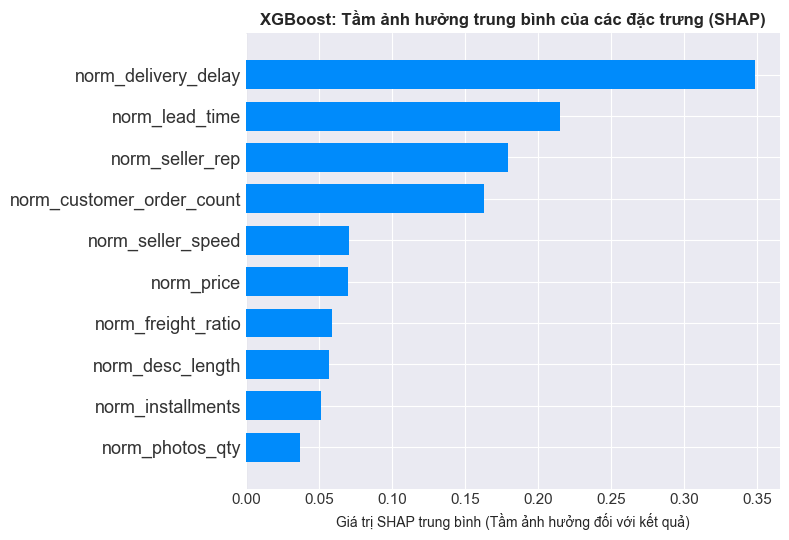

✓ Đã lưu: shap_xgb_bar_plot.png


In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_test, plot_type="bar", show=False)
plt.title('XGBoost: Tầm ảnh hưởng trung bình của các đặc trưng (SHAP)', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị SHAP trung bình (Tầm ảnh hưởng đối với kết quả)', fontsize=10)
plt.tight_layout()
plt.savefig('shap_xgb_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: shap_xgb_bar_plot.png")


### 15.1.3 SHAP Waterfall Plot - Giải thích chi tiết cho các dự đoán cá nhân

Giải thích chi tiết cho 3 dự đoán sai của XGBoost:


📌 Mẫu 1 - Index test = 4592
   Giá trị thực: Không hài lòng
   Dự đoán: Hài lòng
   Xác suất: 0.7345



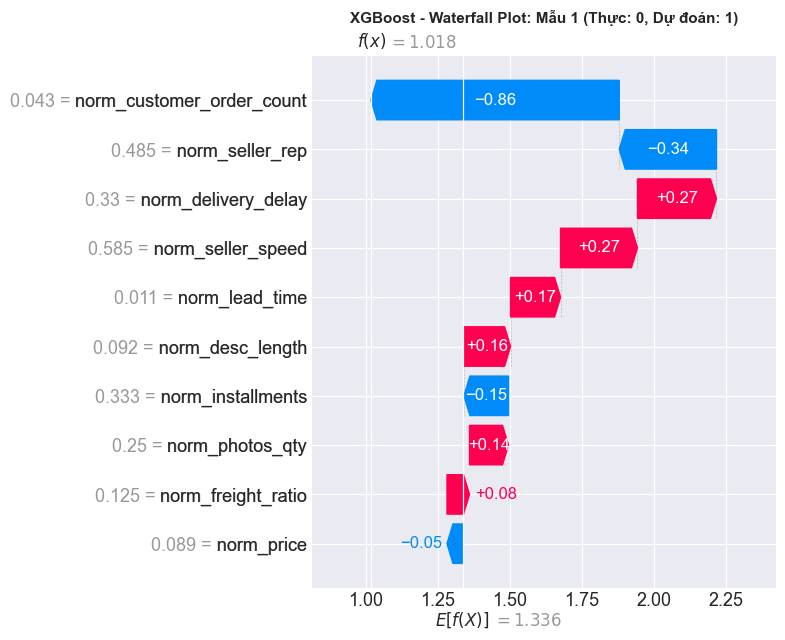


📌 Mẫu 2 - Index test = 2066
   Giá trị thực: Không hài lòng
   Dự đoán: Hài lòng
   Xác suất: 0.7187



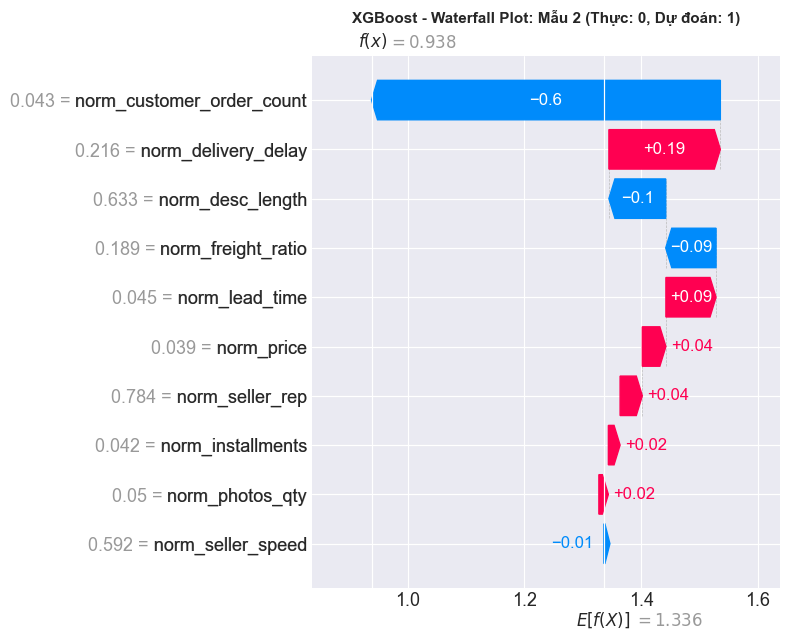


📌 Mẫu 3 - Index test = 13986
   Giá trị thực: Không hài lòng
   Dự đoán: Hài lòng
   Xác suất: 0.8347



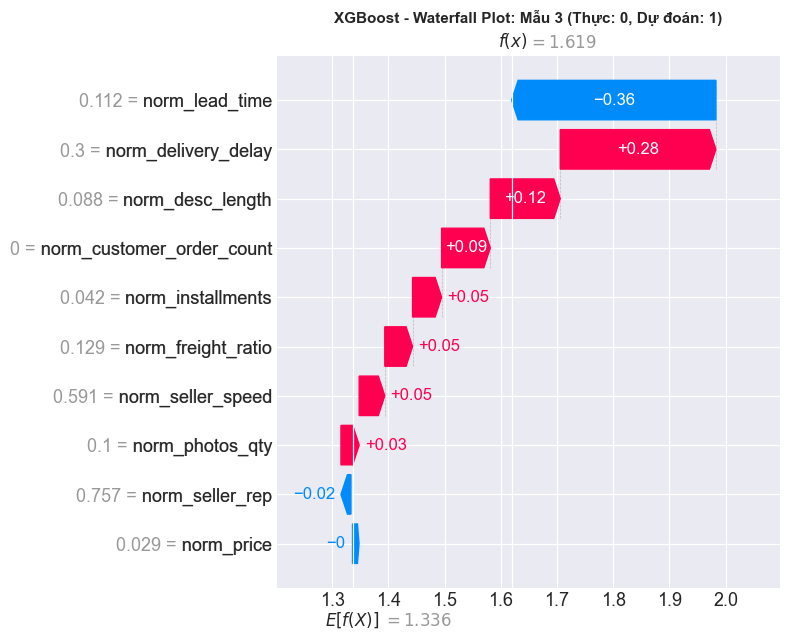


✓ Đã tạo waterfall plots cho các dự đoán sai


In [23]:
# Chọn một vài dự đoán để giải thích chi tiết
# Chọn các sample sai bệnh (mispredicted cases)
incorrect_indices = np.where(y_pred_xgb != y_test.values)[0]

if len(incorrect_indices) > 0:
    # Lấy các sample được dự đoán sai
    sample_indices = np.random.choice(incorrect_indices, size=min(3, len(incorrect_indices)), replace=False)
    
    print(f"Giải thích chi tiết cho {len(sample_indices)} dự đoán sai của XGBoost:\n")
    print("=" * 80)
    
    for i, idx in enumerate(sample_indices, 1):
        print(f"\n📌 Mẫu {i} - Index test = {idx}")
        print(f"   Giá trị thực: {'Hài lòng' if y_test.iloc[idx] == 1 else 'Không hài lòng'}")
        print(f"   Dự đoán: {'Hài lòng' if y_pred_xgb[idx] == 1 else 'Không hài lòng'}")
        print(f"   Xác suất: {y_prob_xgb[idx]:.4f}")
        print()
        
        # Tạo waterfall plot
        fig = plt.figure(figsize=(12, 6))
        shap.waterfall_plot(
            shap.Explanation(
                values=shap_values_xgb[idx],
                base_values=explainer_xgb.expected_value,
                data=X_test.iloc[idx].values,
                feature_names=X_test.columns.tolist()
            ),
            show=False
        )
        plt.title(f'XGBoost - Waterfall Plot: Mẫu {i} (Thực: {y_test.iloc[idx]}, Dự đoán: {y_pred_xgb[idx]})',
                 fontsize=11, fontweight='bold')
        plt.tight_layout()
        plt.savefig(f'shap_waterfall_sample_{i}.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    print("\n" + "=" * 80)
    print("✓ Đã tạo waterfall plots cho các dự đoán sai")
else:
    print("ℹ Không có dự đoán sai để giải thích")


### 15.2 SHAP TreeExplainer cho Random Forest

In [24]:
# Tạo explainer cho Random Forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

print("✓ Tính toán SHAP values cho Random Forest")
print(f"  Đây là bài toán nhị phân, vì vậy SHAP values có 2 lớp")

# Random Forest trả về SHAP values cho cả 2 lớp, lấy lớp "Hài lòng" (index 1)
if isinstance(shap_values_rf, list):
    shap_values_rf_class1 = shap_values_rf[1]  # Lớp "Hài lòng"
else:
    shap_values_rf_class1 = shap_values_rf

print(f"  Shape của SHAP values cho lớp 'Hài lòng': {shap_values_rf_class1.shape}")


✓ Tính toán SHAP values cho Random Forest
  Đây là bài toán nhị phân, vì vậy SHAP values có 2 lớp
  Shape của SHAP values cho lớp 'Hài lòng': (19167, 10, 2)


### 15.2.1 Random Forest - Bar Plot & Beeswarm Plot

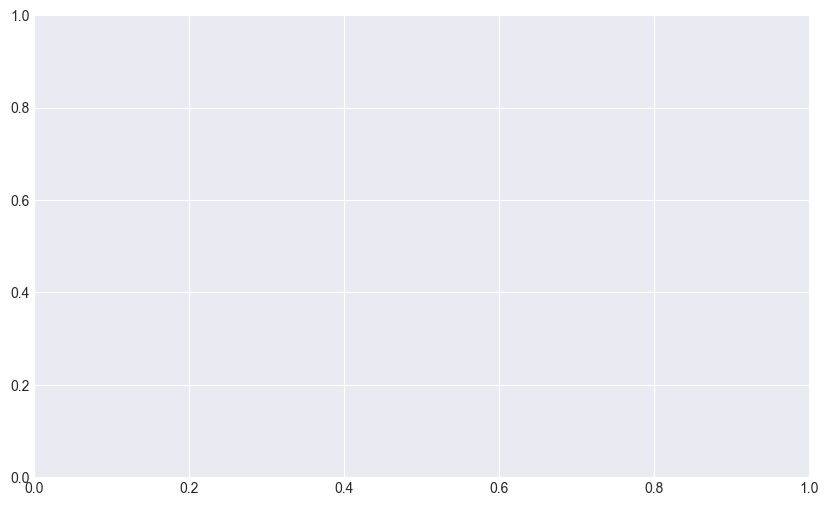

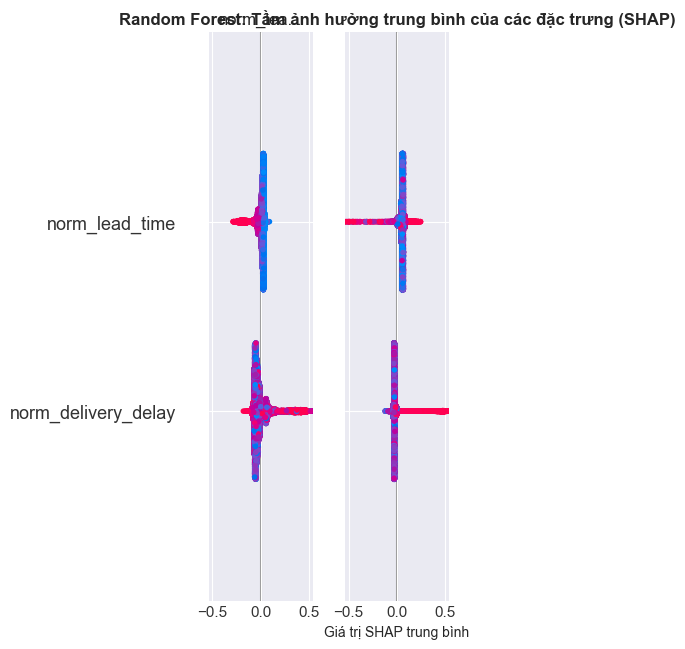

✓ Đã lưu: shap_rf_bar_plot.png


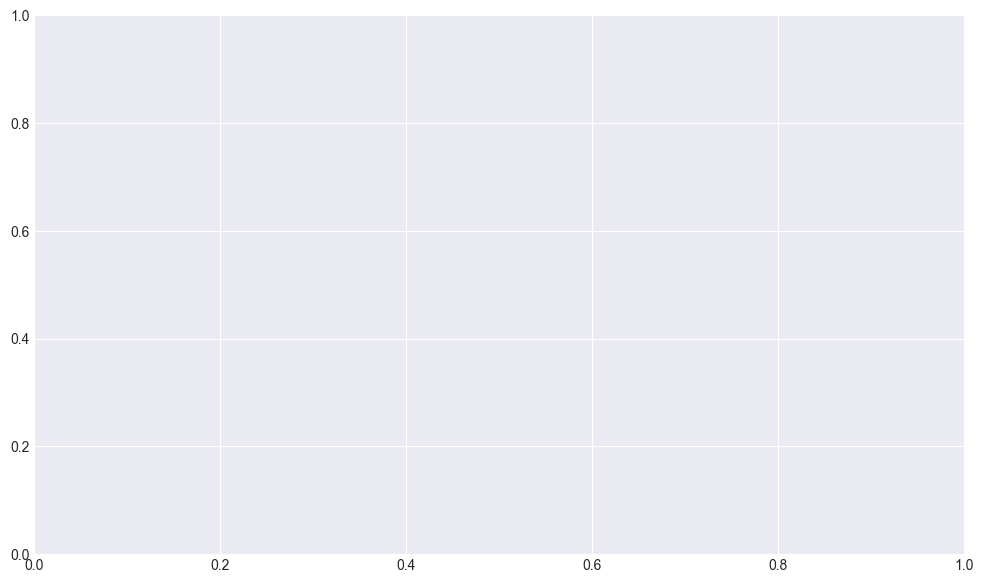

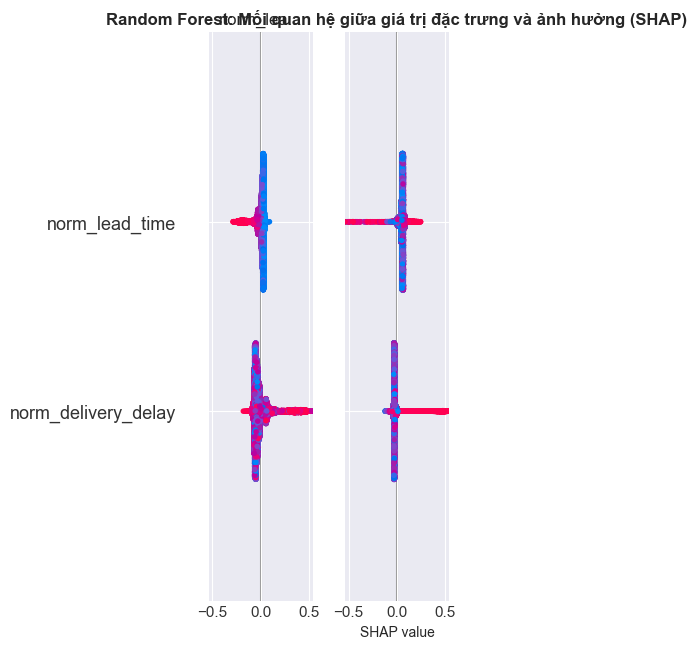

✓ Đã lưu: shap_rf_beeswarm_plot.png


In [25]:
# Bar plot cho Random Forest
fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(shap_values_rf_class1, X_test, plot_type="bar", show=False)
plt.title('Random Forest: Tầm ảnh hưởng trung bình của các đặc trưng (SHAP)', fontsize=12, fontweight='bold')
plt.xlabel('Giá trị SHAP trung bình', fontsize=10)
plt.tight_layout()
plt.savefig('shap_rf_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: shap_rf_bar_plot.png")

# Beeswarm plot cho Random Forest
fig, ax = plt.subplots(figsize=(12, 7))
shap.summary_plot(shap_values_rf_class1, X_test, plot_type="beeswarm", show=False)
plt.title('Random Forest: Mối quan hệ giữa giá trị đặc trưng và ảnh hưởng (SHAP)', fontsize=12, fontweight='bold')
plt.xlabel('SHAP value', fontsize=10)
plt.tight_layout()
plt.savefig('shap_rf_beeswarm_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Đã lưu: shap_rf_beeswarm_plot.png")


## Bước 16 – Tóm tắt SHAP - Đặc trưng quan trọng nhất

In [28]:
# Tính tầm ảnh hưởng trung bình của mỗi đặc trưng cho cả 2 mô hình
feature_importance_xgb = np.abs(shap_values_xgb).mean(axis=0)
feature_importance_rf = np.abs(shap_values_rf_class1).mean(axis=0)

# Ensure both are properly shaped 1D arrays
feature_importance_xgb = np.asarray(feature_importance_xgb).ravel()
feature_importance_rf = np.asarray(feature_importance_rf).ravel()

# Verify they match the number of features
n_features = len(X_test.columns)
if len(feature_importance_xgb) != n_features or len(feature_importance_rf) != n_features:
    print(f"⚠️  Array length mismatch - XGB: {len(feature_importance_xgb)}, RF: {len(feature_importance_rf)}, Features: {n_features}")
    # Take only the first n_features items
    feature_importance_xgb = feature_importance_xgb[:n_features]
    feature_importance_rf = feature_importance_rf[:n_features]

# Tạo dataframe so sánh
shap_comparison = pd.DataFrame({
    'Đặc trưng': list(X_test.columns),
    'XGBoost': feature_importance_xgb,
    'Random Forest': feature_importance_rf
})

# Tính trung bình bình thường hóa
shap_comparison['Trung bình'] = (
    shap_comparison['XGBoost'] + shap_comparison['Random Forest']
) / 2

# Sắp xếp theo tầm ảnh hưởng từ cao xuống thấp
shap_comparison = shap_comparison.sort_values('Trung bình', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("  BẢNG TỔNG HỢP TẦM ẢNH HƯỞNG ĐẶC TRƯNG (SHAP Mean |values|)")
print("=" * 80)
print(shap_comparison.to_string(index=False))
print("=" * 80)

# Lưu bảng so sánh
shap_comparison.to_csv('shap_feature_importance_analysis.csv', index=False)
print("\n✓ Đã lưu: shap_feature_importance_analysis.csv")

# Top 5 đặc trưng quan trọng nhất
print("\n🏆 TOP 5 ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
print("-" * 80)
for idx, row in shap_comparison.head(5).iterrows():
    print(f"{idx + 1}. {row['Đặc trưng']:<30} "
          f"(XGBoost: {row['XGBoost']:.4f}, "
          f"RF: {row['Random Forest']:.4f}, "
          f"Trung bình: {row['Trung bình']:.4f})")
print("-" * 80)


⚠️  Array length mismatch - XGB: 10, RF: 20, Features: 10

  BẢNG TỔNG HỢP TẦM ẢNH HƯỞNG ĐẶC TRƯNG (SHAP Mean |values|)
                Đặc trưng  XGBoost  Random Forest  Trung bình
      norm_delivery_delay 0.348291       0.049900    0.199096
           norm_lead_time 0.215054       0.049900    0.132477
          norm_seller_rep 0.179559       0.005023    0.092291
norm_customer_order_count 0.162962       0.005023    0.083993
        norm_seller_speed 0.070396       0.034837    0.052616
       norm_freight_ratio 0.058504       0.034837    0.046670
               norm_price 0.069385       0.009798    0.039592
        norm_installments 0.051265       0.009798    0.030531
         norm_desc_length 0.056570       0.003387    0.029979
          norm_photos_qty 0.036824       0.003387    0.020106

✓ Đã lưu: shap_feature_importance_analysis.csv

🏆 TOP 5 ĐẶC TRƯNG QUAN TRỌNG NHẤT:
--------------------------------------------------------------------------------
1. norm_delivery_delay           

## Bước 17 – Kết luận và Khuyến nghị từ SHAP Analysis

In [29]:
print("\n" + "=" * 90)
print(" TÓMLƯỢC PHÂN TÍCH SHAP")
print("=" * 90)

print("\n📊 GIẢI THÍCH:")
print("-" * 90)
print("""
SHAP (SHapley Additive exPlanations) là phương pháp giải thích mô hình dựa trên 
game theory để xác định tầm ảnh hưởng của mỗi đặc trưng đối với dự đoán của mô hình.

Các biểu đồ SHAP cho ta thấy:

1. **SHAP Bar Plot**: Đặc trưng nào có ảnh hưởng trung bình lớn nhất đến dự đoán?
   → Các đặc trưng ở trên cùng là quan trọng nhất

2. **SHAP Beeswarm Plot**: Mối quan hệ giữa giá trị đặc trưng và ảnh hưởng:
   → Màu xanh = giá trị thấp, Đỏ = giá trị cao
   → Điểm bên trái = giảm xác suất "Hài lòng"
   → Điểm bên phải = tăng xác suất "Hài lòng"

3. **SHAP Waterfall Plot**: Giải thích chi tiết từng dự đoán
   → Các mũi tên đỏ = tăng xác suất Hài lòng
   → Các mũi tên xanh = giảm xác suất Hài lòng
""")

print("-" * 90)
print("\n🔍 NHỮNG ĐẶC TRƯNG QUAN TRỌNG NHẤT:")
print("-" * 90)

top_5 = shap_comparison.head(5)
for idx, row in top_5.iterrows():
    print(f"   {idx + 1}. {row['Đặc trưng']:<30} → Ảnh hưởng = {row['Trung bình']:.4f}")

print("\n💡 KHUYẾN NGHỊ:")
print("-" * 90)
print("""
• Các đặc trưng hàng đầu nên được theo dõi kỹ lưỡng và tối ưu hóa
• Xem xét tầm ảnh hưởng trong quá trình cải thiện trải nghiệm khách hàng
• Sử dụng SHAP để giải thích các dự đoán cho các bên liên quan
• Các đặc trưng có ảnh hưởng thấp có thể xem xét loại bỏ để đơn giản hóa mô hình
""")

print("\n📁 CÁC TẬP TIN ĐƯỢC TẠO RA:")
print("-" * 90)
print("""
   • shap_xgb_bar_plot.png                 - XGBoost tầm ảnh hưởng trung bình
   • shap_xgb_beeswarm_plot.png           - XGBoost mối quan hệ giá trị-ảnh hưởng
   • shap_waterfall_sample_*.png          - Giải thích chi tiết dự đoán sai
   • shap_rf_bar_plot.png                 - Random Forest tầm ảnh hưởng trung bình
   • shap_rf_beeswarm_plot.png            - Random Forest mối quan hệ giá trị-ảnh hưởng
   • shap_feature_comparison.png          - So sánh XGBoost vs Random Forest
   • shap_feature_importance_analysis.csv - Bảng phân tích chi tiết
""")

print("=" * 90)
print("✅ HOÀN THÀNH PHÂN TÍCH SHAP")
print("=" * 90)



 TÓMLƯỢC PHÂN TÍCH SHAP

📊 GIẢI THÍCH:
------------------------------------------------------------------------------------------

SHAP (SHapley Additive exPlanations) là phương pháp giải thích mô hình dựa trên 
game theory để xác định tầm ảnh hưởng của mỗi đặc trưng đối với dự đoán của mô hình.

Các biểu đồ SHAP cho ta thấy:

1. **SHAP Bar Plot**: Đặc trưng nào có ảnh hưởng trung bình lớn nhất đến dự đoán?
   → Các đặc trưng ở trên cùng là quan trọng nhất

2. **SHAP Beeswarm Plot**: Mối quan hệ giữa giá trị đặc trưng và ảnh hưởng:
   → Màu xanh = giá trị thấp, Đỏ = giá trị cao
   → Điểm bên trái = giảm xác suất "Hài lòng"
   → Điểm bên phải = tăng xác suất "Hài lòng"

3. **SHAP Waterfall Plot**: Giải thích chi tiết từng dự đoán
   → Các mũi tên đỏ = tăng xác suất Hài lòng
   → Các mũi tên xanh = giảm xác suất Hài lòng

------------------------------------------------------------------------------------------

🔍 NHỮNG ĐẶC TRƯNG QUAN TRỌNG NHẤT:
----------------------------------------